In [1]:
'''
    Plot main figures in the paper
'''

import pandas as pd
import numpy as np

import os 
from options.options import Options
import util.util as util
import util.bootstrap_tools as btool

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as plticker

opt = Options()
opt.initialize()

bin_defs = opt.bin_defs
phen_labels = ['AFIB', 'CAD', 'T2D', 'HCA', 'AST', 'OB', 'MDD'] # List of phenotypes

covars = pd.read_csv(opt.env_file, sep='\t', index_col='IID')[opt.covars]
bounds, labels, label_map = util.create_bins_and_indices(covars, bin_defs)

ltril_inds = np.tril_indices(len(opt.labels), -1)

# Load files for each phenotype

In [2]:
all_dict = {}
or_dict = {}
top_or_dict = {}
r2_liab_dict = {}
top_ar_dict = {}
top_ar_null_dict = {}
high_pgs_dict = {}
n_dict = {}
prev_dict = {}
bootstrap_dict = {}
minmax_3way_dict = {}
results_3way_dict = {}
n_3way_dict = {}
pdiff_dict = {}
bot_dict = {}
top_dict = {}

bot_diff_dict = {}
top_diff_dict = {}

for phen in phen_labels:
    all_dict[phen] = np.load(f'results/{phen}/all_results.npy', allow_pickle=True).item()
    or_dict[phen] = np.load(f'results/{phen}/or.npy')
    r2_liab_dict[phen] = np.load(f'results/{phen}/r2_liab.npy')
    top_or_dict[phen] = np.load(f'results/{phen}/top_or.npy')
    top_ar_dict[phen] = np.load(f'results/{phen}/top_ar.npy')
    top_ar_null_dict[phen] = np.load(f'results/{phen}/top_ar_null.npy')
    prev_dict[phen] = np.load(f'results/{phen}/prev.npy')
    n_dict[phen] = np.load(f'results/{phen}/n_idx.npy')
    high_pgs_dict[phen] = np.load(f'results/{phen}/high_pgs.npy')
    
    bootstrap_dict[phen] = np.load(f'results/{phen}/bootstrap.npy', allow_pickle=True).item()
    minmax_3way_dict[phen] = np.load(f'results/{phen}/minmax_3way.npy', allow_pickle=True).item()
    results_3way_dict[phen] = np.load(f'results/{phen}/results_3way.npy', allow_pickle=True).item()
    n_3way_dict[phen] = np.load(f'results/{phen}/n_3way.npy', allow_pickle=True).item()

    pdiff_dict[phen] = np.load(f'results/{phen}/or_pdiff_2way.npy')

    bot_dict[phen] = np.load(f'results/{phen}/bot_results.npy', allow_pickle=True).item()
    top_dict[phen] = np.load(f'results/{phen}/top_results.npy', allow_pickle=True).item()

    bot_diff_dict[phen] = np.load(f'results/{phen}/bot_ar_diff.npy', allow_pickle=True).item()
    top_diff_dict[phen] = np.load(f'results/{phen}/top_ar_diff.npy', allow_pickle=True).item()


n = len(opt.covars)
n_context = n*(n+1)/2

# Determine significance in each two-way variable intersections
pval_zero = {}
pval_parent = {}
pval_zero_summary = np.full((len(phen_labels), n, n), 0)
pval_parent_summary = np.full((len(phen_labels), n, n), 0)
for i, phen in enumerate(phen_labels):
    pval_zero[phen] = np.load(f'results/{phen}/pval_zero.npy')
    pval_parent[phen] = np.load(f'results/{phen}/pval_parent.npy')

    pval_zero_ = pval_zero[phen]<.05/n_context
    pval_zero_summary[i] = pval_zero_
    pval_parent_summary[i] = pval_parent[phen]<.05

sig_twoway_dict = {}

for i_phen, phen in enumerate(phen_labels):
    for i in range(len(opt.covars)):
        for j in range(i):
            if pval_zero_summary[i_phen, i, j] == 1:
                (i_twoway_srt, i_twoway_end) = (bounds[i], bounds[i + 1])
                (j_twoway_srt, j_twoway_end) = (bounds[j], bounds[j + 1])

                pairs = [
                    (x, y)
                    for x in range(i_twoway_srt, i_twoway_end)
                    for y in range(j_twoway_srt, j_twoway_end)
                ]

                if phen not in sig_twoway_dict:
                    sig_twoway_dict[phen] = []

                sig_twoway_dict[phen].extend(pairs)

# Save aggregated data

In [ ]:
pdiff_dict_UKB = {}
for phen in phen_labels:
    pdiff_dict_UKB[phen] = pdiff_dict[phen][:,:,0].copy()

np.save('results/prev_dict_UKB.npy', prev_dict)
np.save('results/pdiff_dict_UKB.npy', pdiff_dict_UKB)
np.save('results/all_dict_UKB.npy', all_dict)
np.save('results/top_or_dict_UKB.npy', top_or_dict)
np.save('results/top_ar_dict_UKB.npy', top_ar_dict)
np.save('results/top_ar_null_dict_UKB.npy', top_ar_null_dict)
np.save('results/top_results_UKB.npy', top_dict)
np.save('results/bot_results_UKB.npy', bot_dict)
np.save('results/top_diff_results_UKB.npy', top_diff_dict)
np.save('results/bot_diff_results_UKB.npy', bot_diff_dict)

# Plot Max OR Δ% across one-, two-, three-way contexts

In [3]:
def find_bootstrap(bootstrap, idx):
    for key in bootstrap.keys():
        for extreme in ['min', 'max']:
            if bootstrap[key][extreme]['index'] == idx:
                return bootstrap[key][extreme]['bootstrap']['top_or']

def calc_pdiff(min_vals, max_vals):
    return 100*(max_vals - min_vals) / min_vals

results_1way = []
results_2way = []
results_3way = []

all_results_1way = []
all_results_2way = []
all_results_3way = []

pdiff_pvals = []
for phen in phen_labels:

    # 1-way analysis
    max_1way_idx = np.argmax(np.diagonal(top_or_dict[phen]))
    min_1way_idx = np.argmin(np.diagonal(top_or_dict[phen]))
    max_1way_coords, min_1way_coords = (max_1way_idx, max_1way_idx), (min_1way_idx, min_1way_idx)
    max_1way_value = top_or_dict[phen][max_1way_coords]
    min_1way_value = top_or_dict[phen][min_1way_coords]
    max_1way_bootstrap = find_bootstrap(bootstrap_dict[phen], max_1way_coords)
    min_1way_bootstrap = find_bootstrap(bootstrap_dict[phen], min_1way_coords)
    pdiff_1way_value = calc_pdiff(min_1way_value, max_1way_value)
    pdiff_1way_bootstrap = calc_pdiff(min_1way_bootstrap, max_1way_bootstrap)
    all_results_1way += [pdiff_1way_bootstrap]
    
    # 2-way analysis
    max_2way_idx = np.nanargmax(top_or_dict[phen][ltril_inds])
    min_2way_idx = np.nanargmin(top_or_dict[phen][ltril_inds])
    max_2way_coords = (ltril_inds[0][max_2way_idx], ltril_inds[1][max_2way_idx])
    min_2way_coords = (ltril_inds[0][min_2way_idx], ltril_inds[1][min_2way_idx])
    max_2way_value = top_or_dict[phen][max_2way_coords]
    min_2way_value = top_or_dict[phen][min_2way_coords]
    max_2way_bootstrap = find_bootstrap(bootstrap_dict[phen], max_2way_coords)
    min_2way_bootstrap = find_bootstrap(bootstrap_dict[phen], min_2way_coords)
    pdiff_2way_value = calc_pdiff(min_2way_value, max_2way_value)
    pdiff_2way_bootstrap = calc_pdiff(min_2way_bootstrap, max_2way_bootstrap)
    all_results_2way += [pdiff_2way_bootstrap]
    
    # 3-way analysis
    max_3way_value = results_3way_dict[phen][minmax_3way_dict[phen]['max']['index']]['top_or']
    min_3way_value = results_3way_dict[phen][minmax_3way_dict[phen]['min']['index']]['top_or']
    max_3way_bootstrap = minmax_3way_dict[phen]['max']['top_or']
    min_3way_bootstrap = minmax_3way_dict[phen]['min']['top_or']
    pdiff_3way_value = calc_pdiff(min_3way_value, max_3way_value)
    pdiff_3way_bootstrap = calc_pdiff(min_3way_bootstrap, max_3way_bootstrap)
    all_results_3way += [pdiff_3way_bootstrap]

    results_1way.append({'mean': pdiff_1way_value, 'ci': util.compute_ci(pdiff_1way_bootstrap)})
    results_2way.append({'mean': pdiff_2way_value, 'ci': util.compute_ci(pdiff_2way_bootstrap)})
    results_3way.append({'mean': pdiff_3way_value, 'ci': util.compute_ci(pdiff_3way_bootstrap)})

    _, one_two = util.calc_empirical_pval(pdiff_2way_bootstrap, pdiff_1way_bootstrap, two_tail=False)
    _, one_three = util.calc_empirical_pval(pdiff_3way_bootstrap, pdiff_1way_bootstrap, two_tail=False)
    _, two_three = util.calc_empirical_pval(pdiff_3way_bootstrap, pdiff_2way_bootstrap, two_tail=False)
    pdiff_pvals += [(one_two, one_three, two_three)]

    print(f"{phen} pvals: {pdiff_pvals[-1]}")

results_1way.append({'mean': np.mean([r['mean'] for r in results_1way]), 'ci': util.compute_ci(np.mean(all_results_1way, axis=0))})
results_2way.append({'mean': np.mean([r['mean'] for r in results_2way]), 'ci': util.compute_ci(np.mean(all_results_2way, axis=0))})
results_3way.append({'mean': np.mean([r['mean'] for r in results_3way]), 'ci': util.compute_ci(np.mean(all_results_3way, axis=0))})

_, one_two = util.calc_empirical_pval(np.mean(all_results_2way, axis=0), np.mean(all_results_1way, axis=0), two_tail=False)
_, one_three = util.calc_empirical_pval(np.mean(all_results_3way, axis=0), np.mean(all_results_1way, axis=0), two_tail=False)
_, two_three = util.calc_empirical_pval(np.mean(all_results_3way, axis=0), np.mean(all_results_2way, axis=0), two_tail=False)

pdiff_pvals += [(one_two, one_three, two_three)]

print("\n")
print(f"One Way:\n\tMean: {np.mean([r['mean'] for r in results_1way])}\n\tCI: {util.compute_ci(np.mean(all_results_1way, axis=0))}")
print(f"Two Way:\n\tMean: {np.mean([r['mean'] for r in results_2way])}\n\tCI: {util.compute_ci(np.mean(all_results_2way, axis=0))}")
print(f"Three Way:\n\tMean: {np.mean([r['mean'] for r in results_3way])}\n\tCI: {util.compute_ci(np.mean(all_results_3way, axis=0))}")

AFIB pvals: (0.022, 0.0028, 0.0924)
CAD pvals: (0.0009, 0.0004, 0.0459)
T2D pvals: (0.0541, 0.0559, 0.1461)
HCA pvals: (0.0597, 0.0003, 0.0303)
AST pvals: (0.0342, 0.0001, 0.0075)
OB pvals: (0.1082, 0.0062, 0.0152)
MDD pvals: (0.1011, 0.0208, 0.1415)


One Way:
	Mean: 26.20330721345963
	CI: (21.616073860680356, 31.151161828409727)
Two Way:
	Mean: 55.96643584311012
	CI: (43.95820160277546, 71.4455217616285)
Three Way:
	Mean: 141.66944801352918
	CI: (104.00280591134978, 202.9818413211136)


# Plot max OR %Δ across one-, two-, and three- way intersections

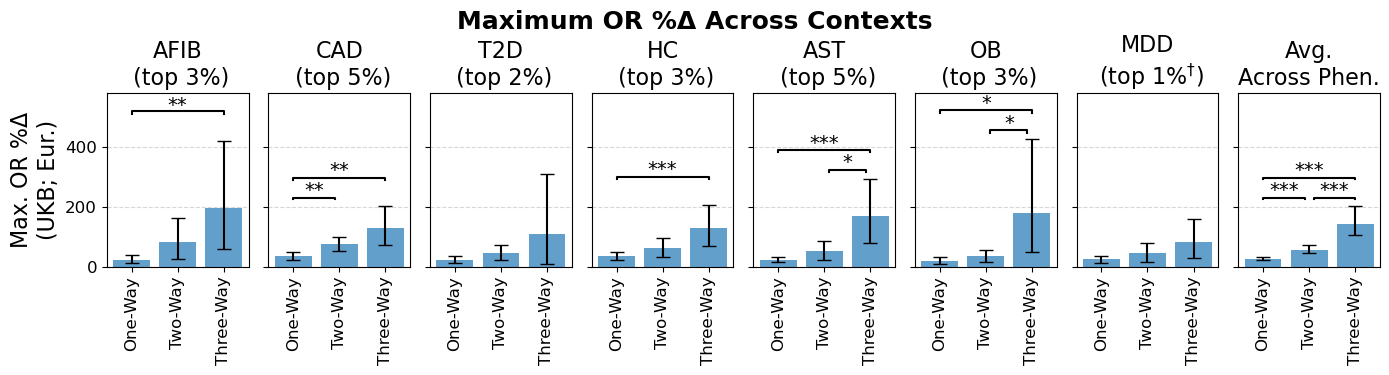

In [4]:
def draw_bracket(ax, pos1, pos2, height, text=None):
    ax.plot([pos1, pos1, pos2, pos2], [height, height * 1.02, height * 1.02, height], 'k-', lw=1.5)
    if text:
        ax.text((pos1 + pos2) * 0.5, height * 1.00 - 1, text, ha='center', va='bottom', fontsize=14)

fig, axes = plt.subplots(1, len(phen_labels)+1, figsize=(2 * len(phen_labels), 4), sharey=True)

for idx, (phen, ax) in enumerate(zip(phen_labels+['Overall'], axes)):
    pdiff_pvals_ = pdiff_pvals[idx]
    means = [result['mean'] for result in [results_1way[idx], results_2way[idx], results_3way[idx]]]
    cis = [result['ci'] for result in [results_1way[idx], results_2way[idx], results_3way[idx]]]
    
    x_labels = ['One-Way', 'Two-Way', 'Three-Way']
    x_positions = np.arange(len(x_labels))
    
    # Extract lower and upper error margins for the CI
    lower_errors = [mean - ci[0] for mean, ci in zip(means, cis)]
    upper_errors = [ci[1] - mean for mean, ci in zip(means, cis)]
    
    # Plot with error bars
    ax.bar(x_positions, means, yerr=[lower_errors, upper_errors], capsize=5, alpha=0.7)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=90, fontsize=12)

    if phen != 'Overall':
        title = opt.phen_params[phen]['title']
        #ax.set_title(phen + f"\n (top {int(100*opt.phen_params[phen]['emerge_cut'])}%$^{\circ}$)", fontsize=16)
        ax.set_title(f"{title}\n (top {int(100*opt.phen_params[phen]['emerge_cut'])}%)", fontsize=16)
        if phen == 'MDD':
            ax.set_title(f"{title}\n (top {int(100*opt.phen_params[phen]['emerge_cut'])}%$^{{†}}$)", fontsize=16)
        if idx == 0:
            ax.set_ylabel('Max. OR %Δ\n(UKB; Eur.)', fontsize=16)
    else:
        ax.set_title(f"Avg.\nAcross Phen.", fontsize=16)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_ylim(0, 580)

    offset = 22
    n_div = 3 # bonferroni correction
    if pdiff_pvals_[0] < 0.05/n_div:
        signif_offset = offset + np.max([ci[1] for ci in cis])
        if pdiff_pvals_[0] < 0.001/n_div:
            draw_bracket(ax, 0, 1 - 0.1, signif_offset, '***')
        elif pdiff_pvals_[0] < 0.01/n_div:
            draw_bracket(ax, 0, 1 - 0.1, signif_offset, '**')
        else:
            draw_bracket(ax, 0, 1 - 0.1, signif_offset, '*')
    if pdiff_pvals_[1] < 0.05/n_div:
        signif_offset = 4 * offset + np.max([ci[1] for ci in cis])
        if pdiff_pvals_[1] < 0.001/n_div:
            draw_bracket(ax, 0, 2, signif_offset, '***')
        elif pdiff_pvals_[1] < 0.01/n_div:
            draw_bracket(ax, 0, 2, signif_offset, '**')
        else:
            draw_bracket(ax, 0, 2, signif_offset, '*')
    if pdiff_pvals_[2] < 0.05/n_div:
        signif_offset = offset + np.max([ci[1] for ci in cis])
        if pdiff_pvals_[2] < 0.001/n_div:
            draw_bracket(ax, 1.1, 2 , signif_offset, '***')
        elif pdiff_pvals_[2] < 0.01/n_div:
            draw_bracket(ax, 1.1, 2 - 0.1, signif_offset, '**')
        else:
            draw_bracket(ax, 1.1, 2 - 0.1, signif_offset, '*')

plt.suptitle("Maximum OR %Δ Across Contexts", fontweight='bold', fontsize=18,  y=.925)

# Adjust layout
plt.tight_layout()
plt.savefig('results/pdiff_extremes.png', bbox_inches='tight')
plt.show()